In [ ]:
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
DATA_PATH = PROJECT_ROOT / "data" / "single-cell-tracks_exp1-6_noErbB2.csv.gz"
META_PATH = PROJECT_ROOT / "data" / "01-readme-experiment-description_2022-04-05.csv"
COMPARE_PATH = SCRIPTS_DIR/'compare_spatiotemporal_behavior.py'

In [11]:
!python3 $COMPARE_PATH --help

usage: compare_spatiotemporal_behavior.py [-h] [--data-path DATA_PATH]
                                          [--meta-path META_PATH]
                                          [--signal-col {ERKKTR_ratio,FoxO3A_ratio}]
                                          [--group-by {auto,conditions,mutation,exp_id,site_id}]
                                          [--spatial-radius SPATIAL_RADIUS]
                                          [--future-window-frames FUTURE_WINDOW_FRAMES]
                                          [--jump-threshold JUMP_THRESHOLD]
                                          [--jump-quantile JUMP_QUANTILE]
                                          [--chunksize CHUNKSIZE]
                                          [--exclude-mutations [EXCLUDE_MUTATIONS ...]]
                                          [--exp-ids [EXP_IDS ...]]
                                          [--site-ids [SITE_IDS ...]]
                                          [--max-blocks MAX_BLOCKS]
       

In [13]:
!python3 $COMPARE_PATH \
    --data-path $DATA_PATH \
    --meta-path $META_PATH \
    --signal-col ERKKTR_ratio \
    --spatial-radius 60.0 \
    --future-window-frames 3 \
    --group-by mutation \
    --output-dir outputs

^C
  File "/opt/anaconda3/lib/python3.11/site-packages/pandas/io/parsers/readers.py", line 1777, in get_chunk
    return self.read(nrows=size)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/pandas/io/parsers/readers.py", line 1748, in read
    ) = self._engine.read(  # type: ignore[attr-defined]
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/pandas/io/parsers/c_parser_wrapper.py", line 234, in read
    chunks = self._reader.read_low_memory(nrows)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "parsers.pyx", line 855, in pandas._libs.parsers.TextReader.read_low_memory
  File "parsers.pyx", line 904, in pandas._libs.parsers.TextReader._read_rows
  File "parsers.pyx", line 879, in pandas._libs.parsers.TextReader._tokenize_rows
  File "parsers.pyx", line 890, in pandas._libs.parsers.TextReader._check_tokenize_status
  File "parsers.pyx", line 2050, in pandas._libs.parsers.raise_pars

In [18]:
import pandas as pd
csv_path = PROJECT_ROOT / 'outputs' / 'comparison_mutation_ERKKTR_ratio'
group_level = pd.read_csv(str(csv_path) + '/group_level_summary.csv')
block_level = pd.read_csv(str(csv_path) + '/block_level_summary.csv')

block_level


,exp_id,site_id,mutation,signal_col,spatial_radius,future_window_frames,jump_threshold,n_nodes,n_spatial_edges,n_temporal_edges,...,n_frames,n_exposed_nodes,n_unexposed_nodes,future_jump_rate_if_neighbor_jumps_now,future_jump_rate_if_no_neighbor_jumps_now,risk_difference,relative_risk,Conditions,group_site_id,comparison_group
0,1,1,WT,ERKKTR_ratio,60.0,3,0.036543,356632,2389504,354834,...,258,146620,210012,0.131455,0.074867,0.056588,1.755850,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,1,WT
1,1,2,WT,ERKKTR_ratio,60.0,3,0.033298,341603,2188412,340009,...,258,133686,207917,0.124665,0.070485,0.054180,1.768681,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,2,WT
2,1,3,WT,ERKKTR_ratio,60.0,3,0.035837,356470,2385276,354785,...,258,146010,210460,0.118889,0.073011,0.045878,1.628362,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,3,WT
3,1,4,WT,ERKKTR_ratio,60.0,3,0.038620,378022,2702454,376126,...,258,161340,216682,0.129614,0.068907,0.060707,1.880994,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,4,WT
4,1,5,AKT1_E17K,ERKKTR_ratio,60.0,3,0.022628,448311,3863383,446302,...,258,224573,223738,0.155272,0.096390,0.058883,1.610885,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,AKT1_E17K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,6,20,PTEN_del,ERKKTR_ratio,60.0,3,0.070620,281048,1515488,279633,...,258,96157,184891,0.116695,0.084217,0.032477,1.385638,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,20,PTEN_del
116,6,21,PTEN_del,ERKKTR_ratio,60.0,3,0.064531,199575,770048,198611,...,258,53732,145843,0.130611,0.081725,0.048886,1.598182,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,21,PTEN_del
117,6,22,PTEN_del,ERKKTR_ratio,60.0,3,0.076808,133887,369683,133262,...,258,27941,105946,0.138077,0.078162,0.059914,1.766534,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,22,PTEN_del
118,6,23,PTEN_del,ERKKTR_ratio,60.0,3,0.066070,165260,555338,164365,...,258,40431,124829,0.131805,0.082905,0.048899,1.589821,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,23,PTEN_del


In [19]:
group_level

,comparison_group,n_blocks,n_unique_sites,n_unique_experiments,total_nodes,mean_relative_risk,median_relative_risk,mean_risk_difference,mean_exposed_jump_rate,mean_unexposed_jump_rate,mean_spatial_edges,mean_temporal_edges
0,PIK3CA_H1047R,24,4,6,4661580,3.200310,3.214033,0.141754,0.207863,0.066110,6.968846e+05,192749.625000
1,WT,24,4,6,7874257,1.742349,1.737245,0.054427,0.127974,0.073547,2.079152e+06,326484.583333
2,PIK3CA_E545K,24,4,6,8443205,1.707110,1.688656,0.059877,0.145206,0.085329,2.385621e+06,349580.125000
3,AKT1_E17K,21,4,6,8797999,1.581421,1.453965,0.053217,0.152170,0.098953,3.450509e+06,417039.285714
4,PTEN_del,27,8,6,5764607,1.556633,1.555826,0.045523,0.127909,0.082386,9.433794e+05,212421.111111


In [23]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

per_group = group_level[['comparison_group', 'mean_relative_risk']]
per_mutation = block_level[['mutation', 'relative_risk']]

mutation_std = per_mutation.groupby('mutation')['relative_risk'].std().reset_index()

per_group = per_group.merge(
    mutation_std.rename(columns={'mutation': 'comparison_group', 'relative_risk': 'std_relative_risk'}),
    on='comparison_group',
    how='left'
)

wt_relative_risk = per_mutation[per_mutation['mutation'] == 'WT']['relative_risk']

mannwhitney_rows = []
for mutation in per_mutation['mutation'].unique():
    if mutation == 'WT':
        continue
    mutation_relative_risk = per_mutation[per_mutation['mutation'] == mutation]['relative_risk']
    stat, pval = mannwhitneyu(wt_relative_risk, mutation_relative_risk, alternative='two-sided')
    mannwhitney_rows.append({
        'mutation': mutation,
        'statistic': stat,
        'p_raw': pval,
        'mean_RR_mutation': mutation_relative_risk.mean(),
        'mean_RR_WT': wt_relative_risk.mean()
    })
mannwhitney_df = pd.DataFrame(mannwhitney_rows)

alpha = 0.05
adjusted_alpha = alpha / len(mannwhitney_df)
mannwhitney_df['significant'] = mannwhitney_df['p_raw'] < adjusted_alpha

# mannwhitney_df
# per_group
# per_mutation

mutations_comparison_table = per_group.merge(
    mannwhitney_df[['mutation','p_raw','significant']],
    left_on='comparison_group',
    right_on='mutation',
    how='left'
)

mutations_comparison_table = mutations_comparison_table.drop(columns=['mutation'])
mutations_comparison_table.to_csv((str(PROJECT_ROOT)+ '/outputs/mutations_comparison_table.csv'), index=False)


mutations_comparison_table

,comparison_group,mean_relative_risk,std_relative_risk,p_raw,significant
0,PIK3CA_H1047R,3.200310,0.640017,3.063664e-09,True
1,WT,1.742349,0.084226,NaN,NaN
2,PIK3CA_E545K,1.707110,0.156202,1.835290e-01,False
3,AKT1_E17K,1.581421,0.329635,3.461467e-03,True
4,PTEN_del,1.556633,0.112361,3.660584e-07,True


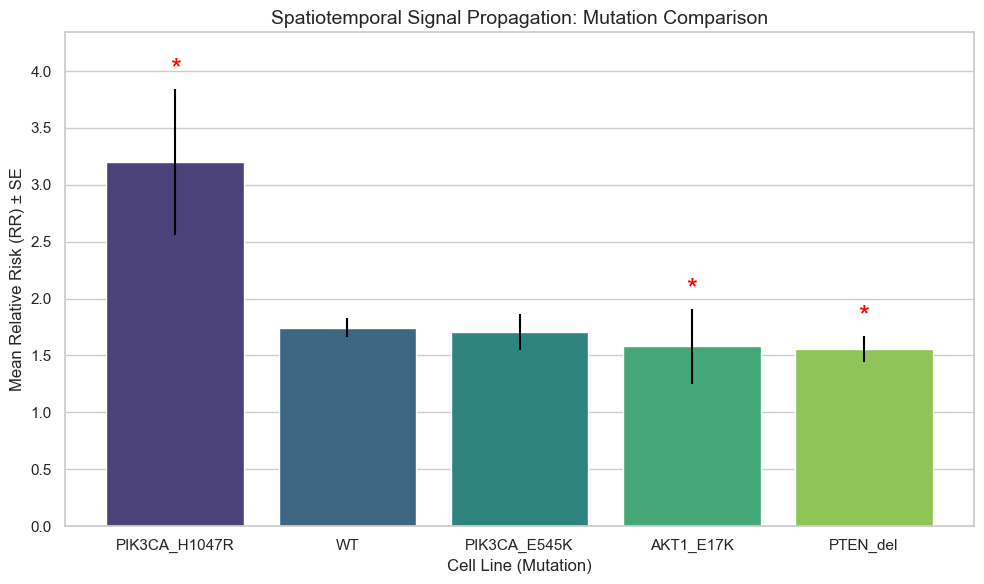

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

mutations_comparison_table = pd.read_csv((str(PROJECT_ROOT)+ '/outputs/mutations_comparison_table.csv'))

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

barplot = sns.barplot(
    data=mutations_comparison_table, 
    x='comparison_group', 
    y='mean_relative_risk', 
    palette='viridis',
    capsize=.1
)

plt.errorbar(
    x=range(len(mutations_comparison_table)), 
    y=mutations_comparison_table['mean_relative_risk'], 
    yerr=mutations_comparison_table['std_relative_risk'], 
    fmt='none', 
    c='black'
)

for i, row in mutations_comparison_table.iterrows():
    if row['significant'] == True:
        y_pos = row['mean_relative_risk'] + row['std_relative_risk'] + 0.05
        plt.text(i, y_pos, '*', ha='center', va='bottom', fontsize=20, color='red')

plt.title('Spatiotemporal Signal Propagation: Mutation Comparison', fontsize=14)
plt.ylabel('Mean Relative Risk (RR) ± SE', fontsize=12)
plt.xlabel('Cell Line (Mutation)', fontsize=12)
plt.ylim(0, mutations_comparison_table['mean_relative_risk'].max() + mutations_comparison_table['std_relative_risk'].max() + 0.5)

plt.tight_layout()
plt.savefig((str(PROJECT_ROOT)+ '/outputs/mutations_barplot.png'), dpi=300)
plt.show()